# SSE Detection Manuscript Figures and Tables

This notebook is the manuscript build sheet for SSE detection outputs. It loads the processed analysis tables, renders publication-context figures, and writes consistently named figure and table files under `sse_detection/manuscript`.


## Build Settings

All plots use the project `paper` context. Figure and table names are defined in the notebook rather than inside plotting helpers, so numbering and filenames can be changed in one place before export.


In [18]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

%load_ext autoreload
%autoreload 2

PROJECT_ROOT = Path("/Users/ydnkka/Desktop/PhD Project/projects/scotland")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import utils  # noqa: E402
from sse_detection import lib as sselib  # noqa: E402

PLOT_CONTEXT = "paper"
SAVE_OUTPUTS = os.environ.get("SSE_SAVE_OUTPUTS", "1").lower() not in {"0", "false", "no"}
DISPLAY_FIGURES = os.environ.get("SSE_DISPLAY_FIGURES", "1").lower() not in {"0", "false", "no"}

OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "results" / "sse_outputs"
ASSOCIATION_DIR = PROJECT_ROOT / "sse_detection" / "results" / "association_outputs"
CLADE_ASSOCIATION_DIR = PROJECT_ROOT / "sse_detection" / "results" / "sensitivity_clade"
RESULTS_DIR = PROJECT_ROOT / "sse_detection" / "results"
GEOGRAPHY_PATH = PROJECT_ROOT / "data" / "processed" / "scotland_geography.parquet"
ANALYSIS_DATASET = PROJECT_ROOT / "data" / "processed" / "scotland_clustering_analysis_dataset.parquet"

EXPORT_DIR = PROJECT_ROOT / "sse_detection" / "manuscript"
FIG_DIR = EXPORT_DIR / "figures"
TABLE_DIR = EXPORT_DIR / "tables"
for directory in (FIG_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

utils.set_theme(context=PLOT_CONTEXT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
figure_exports: list[dict[str, object]] = []
table_exports: list[dict[str, object]] = []


def export_figure(
    fig,
    stem: str,
    *,
    width: utils.WIDTHS = "double",
    width_in: float | None = None,
    height_in: float | None = None,
    close_if_not_saved: bool = False,
) -> None:
    """Display and optionally save one manuscript figure."""
    if DISPLAY_FIGURES:
        display(fig)

    paths = {}
    if SAVE_OUTPUTS:
        paths = utils.save_figure(
            fig,
            FIG_DIR / stem,
            width=width,
            width_in=width_in,
            height_in=height_in,
            save_pdf=True,
            save_png=True,
        )
    elif close_if_not_saved or not DISPLAY_FIGURES:
        plt.close(fig)

    figure_exports.append(
        {
            "stem": stem,
            "width": width,
            "width_in": width_in,
            "height_in": height_in,
            "pdf": paths.get("pdf"),
            "png": paths.get("png"),
        }
    )


def export_table(table: pd.DataFrame, stem: str) -> None:
    """Save one manuscript table CSV and record its row/column count."""
    path = TABLE_DIR / f"{stem}.csv"
    if SAVE_OUTPUTS:
        table.to_csv(path, index=False)
    table_exports.append(
        {
            "stem": stem,
            "rows": len(table),
            "columns": len(table.columns),
            "path": path if SAVE_OUTPUTS else None,
        }
    )

## Load SSE Output Tables

These are the static outputs from the SSE detection pipeline. The summary table is exported as the first manuscript table because it anchors the denominator for downstream figures.


In [20]:
outs = sselib.load_sse_outputs(OUTPUT_DIR)
node_stats = outs.node_stats
edge_table = outs.edge_table
candidate_review = outs.candidate_review
meta_summary = outs.meta_summary
candidates = outs.candidates

min_size = int(node_stats.loc[node_stats["sse_candidate"], "cluster_size"].min())
background_nodes = int(
    node_stats["cluster_size"].ge(min_size).sum()
    - node_stats["sse_candidate"].sum()
)

output_summary = pd.DataFrame(
    [
        ("node-clusters", len(node_stats)),
        ("directed edges", len(edge_table)),
        ("meta-clusters", meta_summary["meta_cluster_id"].nunique()),
        ("SSE-like candidate nodes", int(node_stats["sse_candidate"].sum())),
        ("candidate share of nodes", float(node_stats["sse_candidate"].mean())),
        (f"background nodes (cluster size >= {min_size})", background_nodes),
        (
            f"background share of nodes (cluster size >= {min_size})",
            background_nodes / len(node_stats),
        ),
        ("unique candidate categories", candidates["sse_category"].nunique()),
    ],
    columns=["quantity", "value"],
)
output_summary["display_value"] = output_summary["value"].map(
    lambda value: (
        f"{value:,.1%}"
        if isinstance(value, float) and abs(value) < 1
        else f"{value:,.0f}"
        if pd.notna(value)
        else "NA"
    )
)

display(output_summary[["quantity", "display_value"]])
export_table(output_summary, "table01_sse_output_summary")

,quantity,display_value
0,node-clusters,"99,006"
1,directed edges,"41,747"
2,meta-clusters,"57,354"
3,SSE-like candidate nodes,"6,907"
4,candidate share of nodes,7.0%
5,background nodes (cluster size >= 6),"6,152"
6,background share of nodes (cluster size >= 6),6.2%
7,unique candidate categories,8


## Descriptive SSE Figures

These figures describe the detected candidate nodes, their meta-cluster context, temporal dynamics, and score distributions. The filenames use the manuscript figure order plus short content labels.


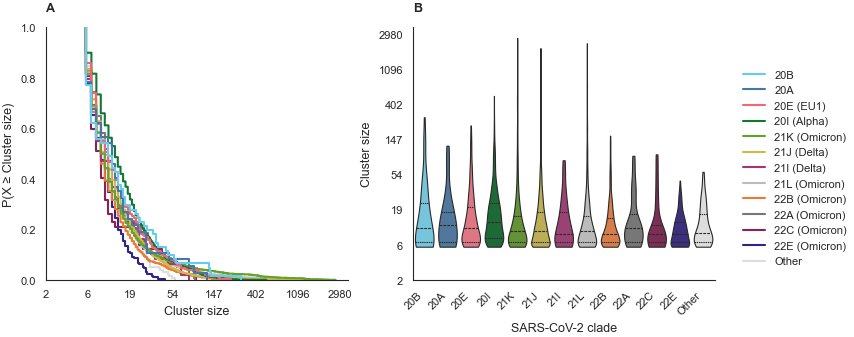

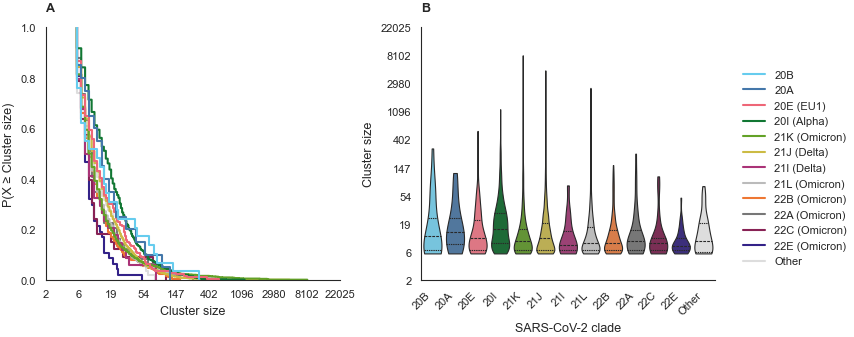

In [21]:
descriptive_figures = [
    (
        "fig01_cluster_size_distribution",
        sselib.plot_cluster_size_distribution(
            node_stats,
            min_size=min_size,
            context=PLOT_CONTEXT,
            height_in=3.4,
        ),
        {"width": "double", "height_in": 3.4},
    ),
    (
        "fig02_meta_cluster_size_distribution",
        sselib.plot_cluster_size_distribution(
            meta_summary,
            size_col="n_sequences",
            is_log1p=False,
            min_size=min_size,
            context=PLOT_CONTEXT,
            height_in=3.4,
        ),
        {"width": "double", "height_in": 3.4},
    ),
]

for stem, fig, kwargs in descriptive_figures:
    export_figure(fig, stem, **kwargs)

In [37]:
role_summary = (
    node_stats.groupby("meta_cluster_id")["sse_role"]
    .nunique()
    .reset_index(name="n_roles_represented")
)
exemplar_meta_clusters = role_summary.sort_values(
    ["n_roles_represented", "meta_cluster_id"],
    ascending=[False, True],
)["meta_cluster_id"][:10]

print(exemplar_meta_clusters)

0     AM00001
1     AM00002
6     AM00007
8     AM00009
10    AM00011
11    AM00012
14    AM00015
26    AM00027
27    AM00028
31    AM00032
Name: meta_cluster_id, dtype: str


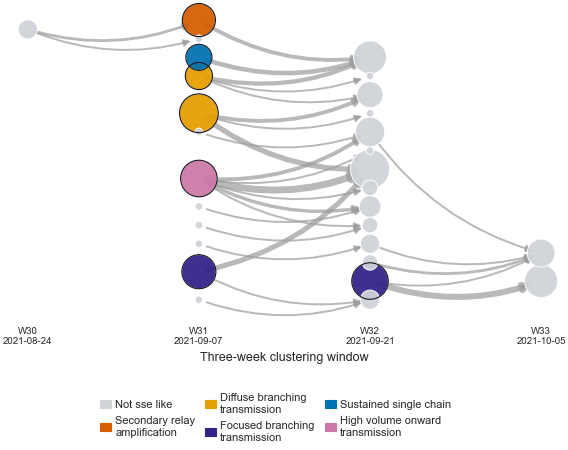

In [42]:
fig = sselib.plot_meta_cluster_subgraph(
    node_stats=node_stats,
    edge_table=edge_table,
    meta_cluster_id="AM00027",
    color_by="sse_category",
    annotate_top_n=0,
    rankdir="LR",
    width="double",
    height_in=5.3,
    context=PLOT_CONTEXT,
)
export_figure(
    fig,
    "fig03_meta_cluster_subgraph",
    width="double",
    height_in=5.3,
)

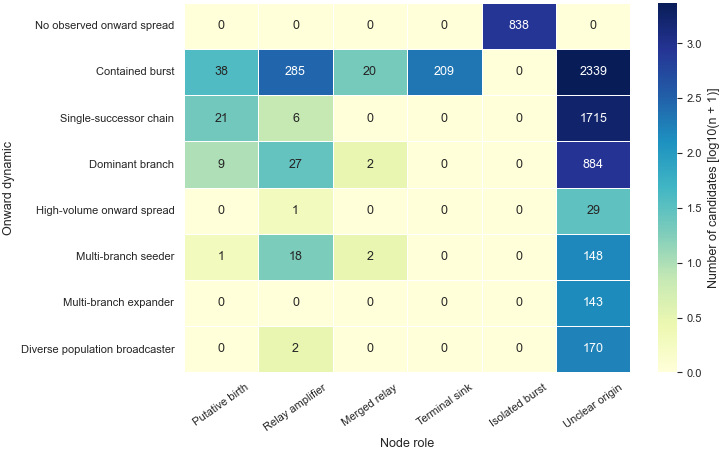

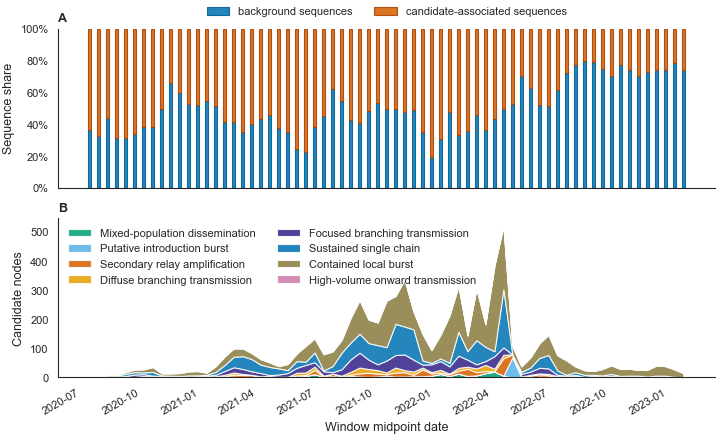

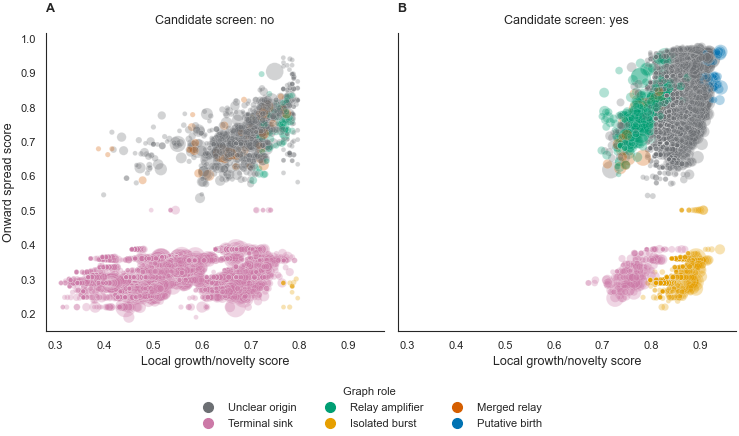

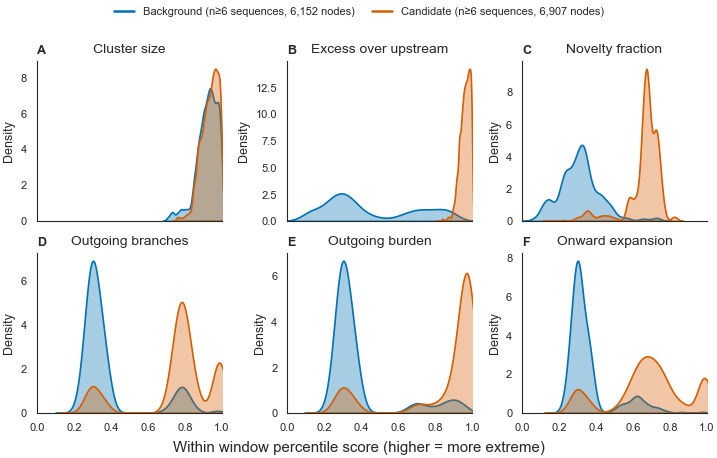

In [23]:
descriptive_figures = [
    (
        "fig04_sse_role_onward_heatmap",
        sselib.plot_role_dynamic_heatmap(
            candidates,
            context=PLOT_CONTEXT,
            height_in=4.8,
        ),
        {"width": "double", "height_in": 4.8},
    ),
    (
        "fig05_candidate_rate_over_time",
        sselib.plot_candidate_rate_over_time(
            node_stats,
            context=PLOT_CONTEXT,
            height_in=4.4,
        ),
        {"width": "double", "height_in": 4.4},
    ),
    (
        "fig06_core_metric_space",
        sselib.plot_core_metric_space(
            node_stats,
            min_size=min_size,
            context=PLOT_CONTEXT,
            height_in=3.8,
        ),
        {"width": "double", "height_in": 3.8},
    ),
    (
        "fig07_composite_score_distributions",
        sselib.plot_composite_distributions(
            node_stats,
            min_size=min_size,
            context=PLOT_CONTEXT,
            width="double",
            height_in=4.2,
        ),
        {"width": "double", "height_in": 4.2},
    ),
]

for stem, fig, kwargs in descriptive_figures:
    export_figure(fig, stem, **kwargs)

## Composition and Mixing Breakdown Figures

Each figure pairs candidate/background mixing-score distributions with the observed category composition for the same predictor family.


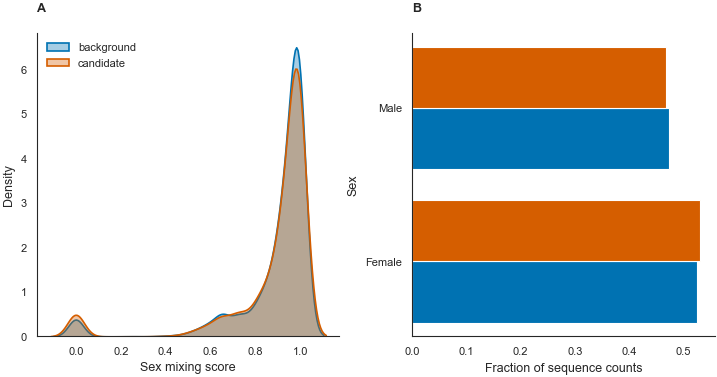

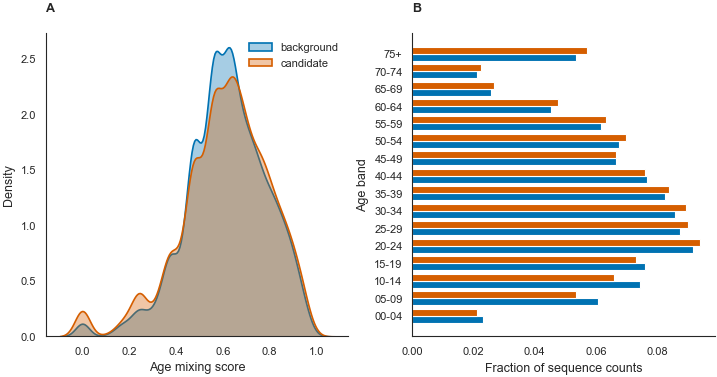

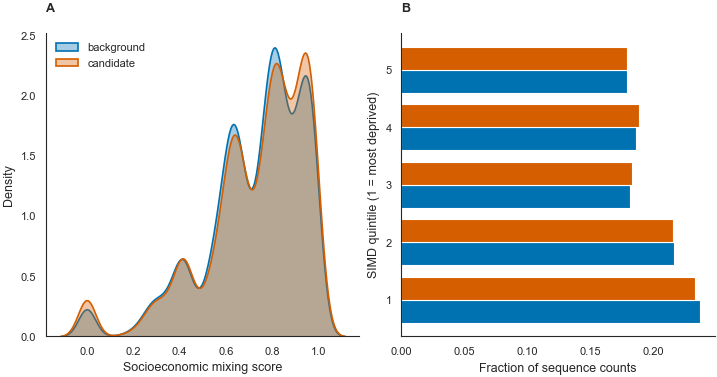

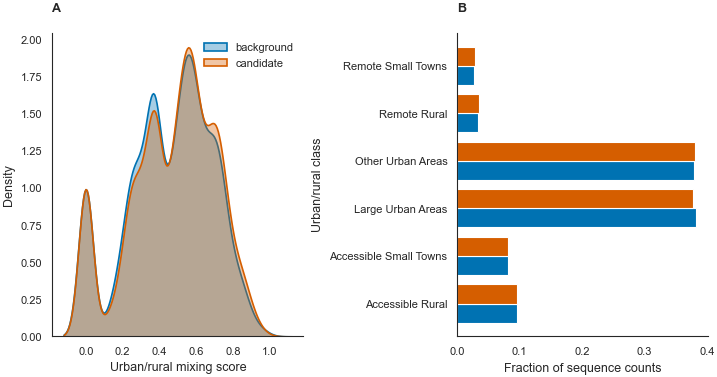

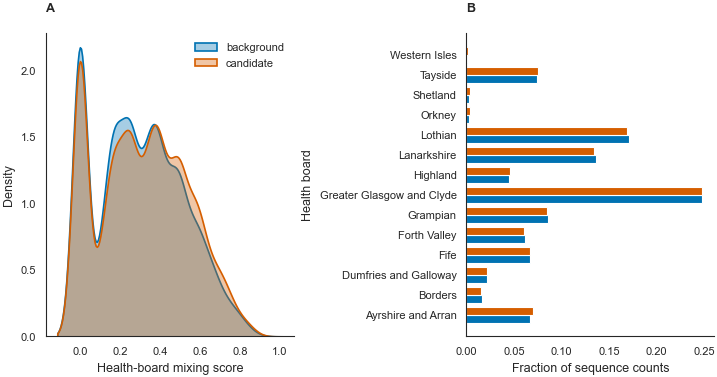

In [24]:
socio_demo_specs = [
    (
        "fig08a_sex_mixing_breakdown",
        "sex_counts",
        "sex_entropy_obs",
        ("Sex mixing score", "Sex"),
    ),
    (
        "fig08b_age_mixing_breakdown",
        "age_band_counts",
        "age_entropy_obs",
        ("Age mixing score", "Age band"),
    ),
    (
        "fig08c_simd_mixing_breakdown",
        "simd_quintile_counts",
        "simd_entropy_obs",
        ("Socioeconomic mixing score", "SIMD quintile (1 = most deprived)"),
    ),
    (
        "fig08d_urban_rural_mixing_breakdown",
        "urban_rural_class_counts",
        "urban_rural_entropy_obs",
        ("Urban/rural mixing score", "Urban/rural class"),
    ),
    (
        "fig08e_health_board_mixing_breakdown",
        "health_board_counts",
        "health_board_entropy_obs",
        ("Health-board mixing score", "Health board"),
    ),
]

for stem, col, score, labels in socio_demo_specs:
    fig = sselib.plot_socio_demo_breakdown(
        node_stats,
        min_size=min_size,
        col=col,
        score=score,
        labels=labels,
        context=PLOT_CONTEXT,
        height_in=3.8,
    )
    export_figure(fig, stem, width="double", height_in=3.8)

## Regression Association Tables

The association pipeline writes separate composition and mixing CSVs. This section normalizes those tables and exports manuscript-facing Wald, odds-ratio, and fit-statistics tables.


In [25]:
def read_analysis_table(path: Path) -> pd.DataFrame:
    table = pd.read_csv(path, skipinitialspace=True)
    table.columns = [str(col).strip() for col in table.columns]
    for col in table.select_dtypes(include=["object", "string"]).columns:
        present = table[col].notna()
        table.loc[present, col] = table.loc[present, col].astype(str).str.strip()
    return table


required_association_files = {
    "composition_wald": "composition_wald.csv",
    "composition_or": "composition_odds_ratios.csv",
    "composition_fit": "composition_fit_stats.csv",
    "mixing_wald": "mixing_wald.csv",
    "mixing_or": "mixing_odds_ratios.csv",
    "mixing_fit": "mixing_fit_stats.csv",
}

association_tables = {
    key: read_analysis_table(ASSOCIATION_DIR / filename)
    for key, filename in required_association_files.items()
}

composition_wald = association_tables["composition_wald"]
composition_or = association_tables["composition_or"]
composition_fit = association_tables["composition_fit"]
mixing_wald = association_tables["mixing_wald"]
mixing_or = association_tables["mixing_or"]
mixing_fit = association_tables["mixing_fit"]

In [26]:
MIXING_REFERENCE = "per 1-SD null-model expectation"


def fill_reference_scale(table: pd.DataFrame, value: str) -> pd.DataFrame:
    table = table.copy()
    if "Reference/scale" in table.columns:
        table["Reference/scale"] = (
            table["Reference/scale"].replace("", pd.NA).fillna(value)
        )
    return table


regression_tables = {
    "table02_composition_wald_tests": sselib.make_regression_wald_table(
        composition_wald,
        domain="composition",
    ),
    "table03_composition_odds_ratios": sselib.make_regression_odds_ratio_table(
        composition_or,
        domain="composition",
    ),
    "table04_composition_fit_stats": sselib.make_regression_fit_table(
        composition_fit,
        domain="composition",
    ),
    "table05_mixing_wald_tests": fill_reference_scale(
        sselib.make_regression_wald_table(
            mixing_wald,
            domain="node_mixing",
        ),
        MIXING_REFERENCE,
    ),
    "table06_mixing_odds_ratios": fill_reference_scale(
        sselib.make_regression_odds_ratio_table(
            mixing_or,
            domain="node_mixing",
        ),
        MIXING_REFERENCE,
    ),
    "table07_mixing_fit_stats": sselib.make_regression_fit_table(
        mixing_fit,
        domain="node_mixing",
    ),
}

for stem, table in regression_tables.items():
    export_table(table, stem)

display(pd.DataFrame(table_exports).tail(len(regression_tables)))

,stem,rows,columns,path
1,table02_composition_wald_tests,20,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
2,table03_composition_odds_ratios,152,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
3,table04_composition_fit_stats,12,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
4,table05_mixing_wald_tests,12,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
5,table06_mixing_odds_ratios,20,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
6,table07_mixing_fit_stats,12,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...


## Regression Association Figures

The Wald heatmap uses the omnibus test tables. The forest plot and map use odds ratios from the primary single/joint specifications, keeping the presentation focused on interpretable effect sizes.


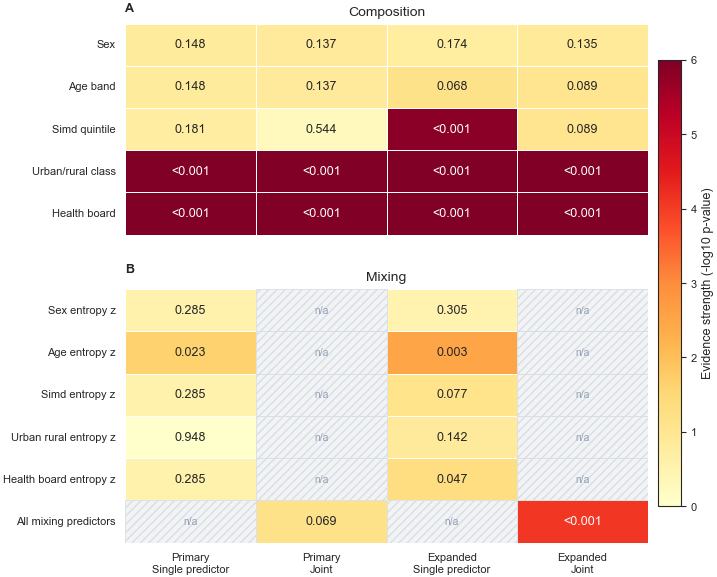

In [27]:
fig = sselib.plot_regression_wald_heatmap(
    composition_wald,
    mixing_wald,
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
    cap_neg_log10_p=6,
)
export_figure(
    fig,
    "fig09_regression_wald_heatmap",
    width="double",
    height_in=5.8,
)

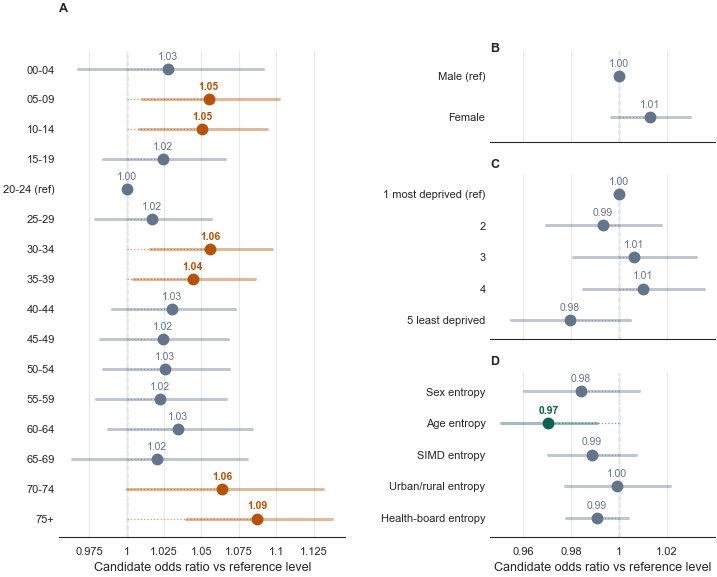

In [28]:
fig = sselib.plot_age_sex_simd_forest(
    composition_odds_ratios=composition_or,
    mixing_odds_ratios=mixing_or,
    predictor_set="single",
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
)
export_figure(
    fig,
    "fig10_age_sex_simd_mixing_forest",
    width="double",
    height_in=5.8,
)


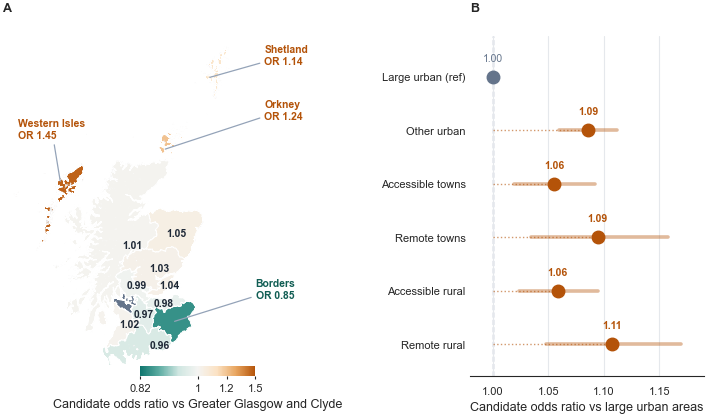

In [29]:
fig = sselib.plot_health_board_enrichment_map(
    GEOGRAPHY_PATH,
    composition_or,
    context=PLOT_CONTEXT,
    width="double",
    height_in=4.2,
)
export_figure(
    fig,
    "fig11_health_board_urban_rural_enrichment",
    width="double",
    height_in=4.2,
)


## Sensitivity Analysis Figure

This matrix summarizes whether composition and mixing Wald tests remain significant across sensitivity runs, including the joint mixing row where available.


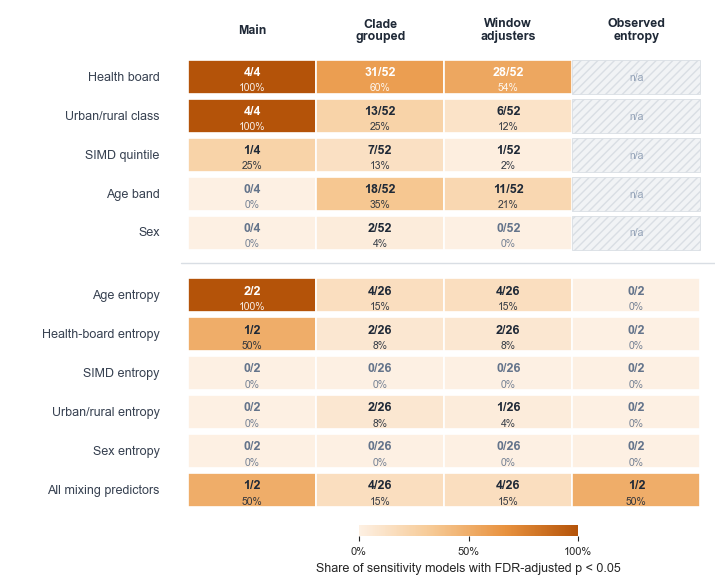

In [30]:
fig = sselib.plot_sensitivity_matrix(
    RESULTS_DIR,
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
)
export_figure(
    fig,
    "fig12_sensitivity_wald_matrix",
    width="double",
    height_in=5.8,
)


## Clade-Stratified Association Figures and Tables

The clade helper returns dictionaries of figures and summary tables without saving. The notebook maps those stable keys to the manuscript filenames below.


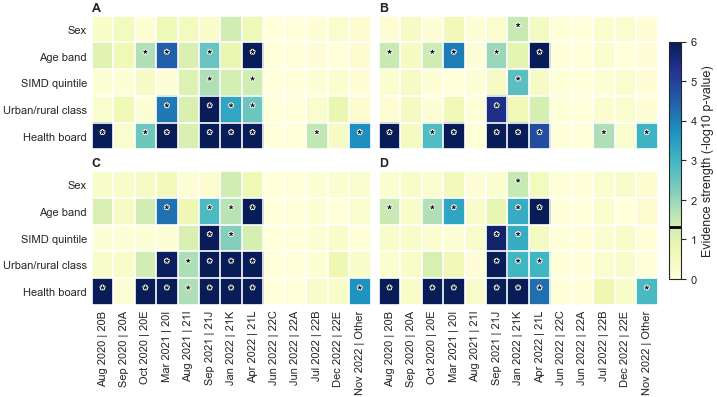

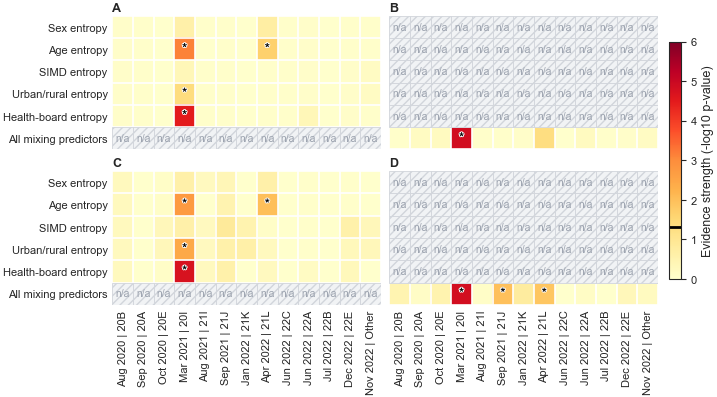

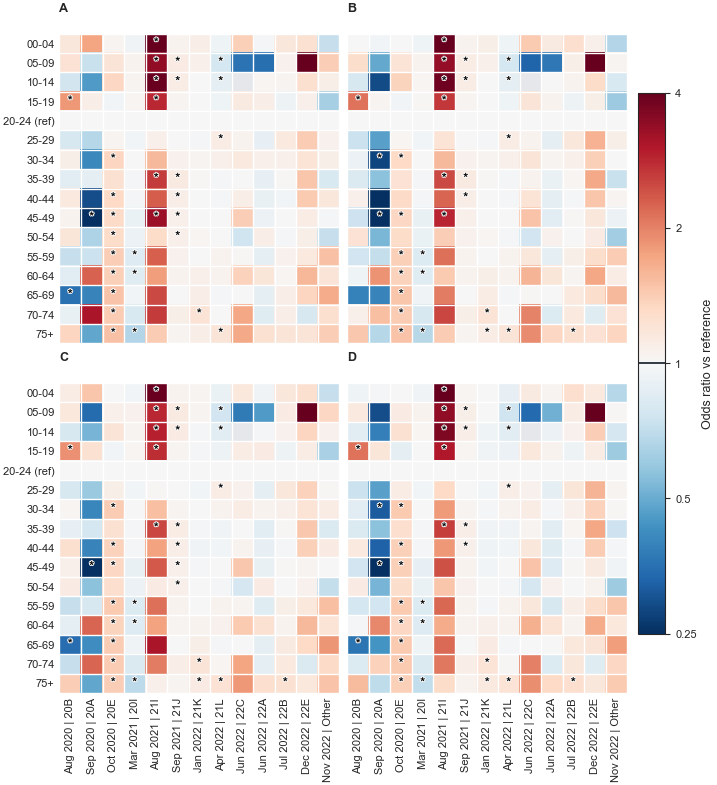

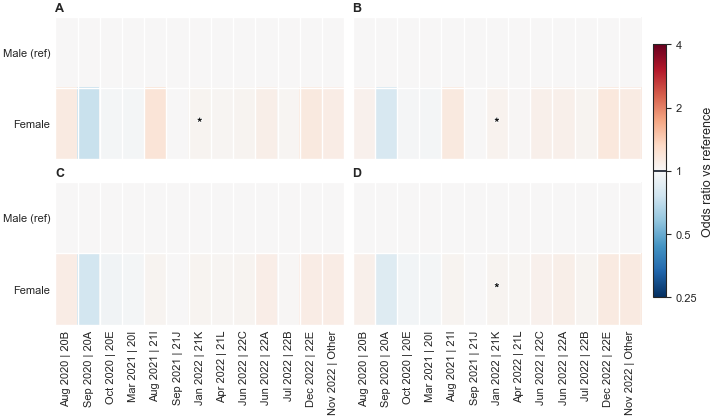

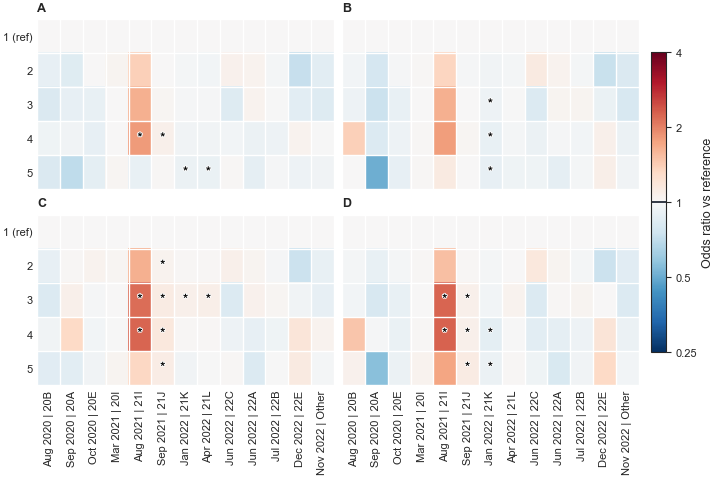

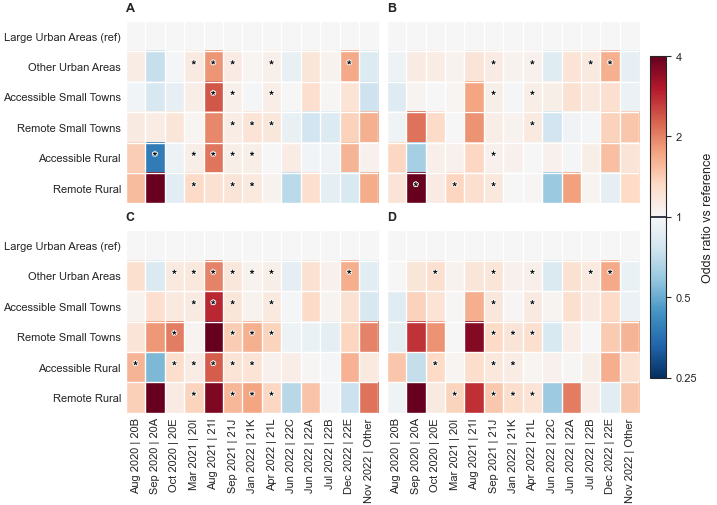

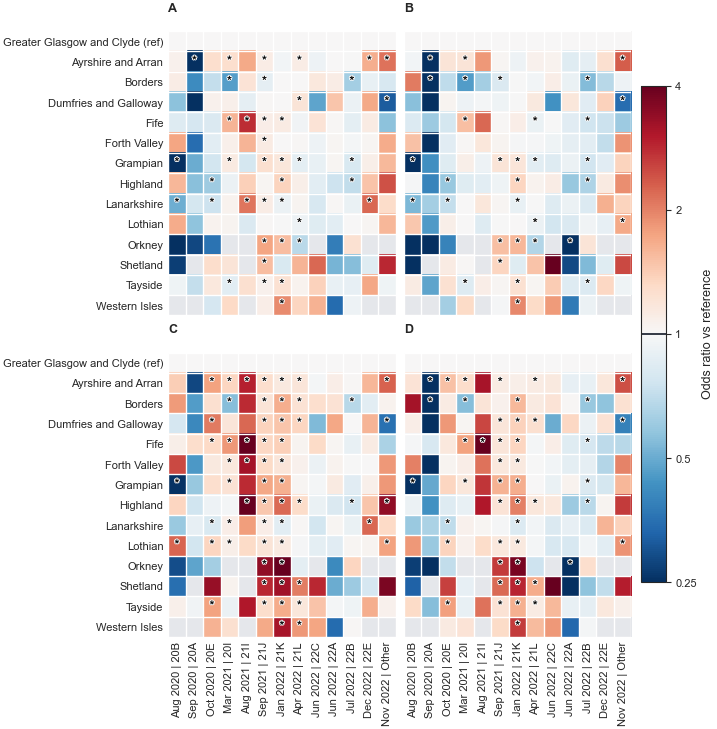

In [31]:
clade_figures, clade_tables = sselib.make_clade_association_outputs(
    results_dir=CLADE_ASSOCIATION_DIR,
    analysis_dataset=ANALYSIS_DATASET,
)

clade_figure_names = {
    "clade_composition_significance": "fig13_clade_composition_wald_heatmap",
    "clade_mixing_significance": "fig14_clade_mixing_wald_heatmap",
    "clade_composition_or_age_band": "fig15_clade_age_band_or_heatmap",
    "clade_composition_or_sex": "fig16_clade_sex_or_heatmap",
    "clade_composition_or_simd_quintile": "fig17_clade_simd_or_heatmap",
    "clade_composition_or_urban_rural_class": "fig18_clade_urban_rural_or_heatmap",
    "clade_composition_or_health_board": "fig19_clade_health_board_or_heatmap",
}

for source_key, stem in clade_figure_names.items():
    export_figure(clade_figures[source_key], stem, width="double")


In [32]:
clade_figures

{'clade_composition_significance': <Figure size 720x400 with 5 Axes>,
 'clade_mixing_significance': <Figure size 720x400 with 5 Axes>,
 'clade_composition_or_age_band': <Figure size 720x788 with 5 Axes>,
 'clade_composition_or_sex': <Figure size 720x420 with 5 Axes>,
 'clade_composition_or_simd_quintile': <Figure size 720x480 with 5 Axes>,
 'clade_composition_or_urban_rural_class': <Figure size 720x508 with 5 Axes>,
 'clade_composition_or_health_board': <Figure size 720x732 with 5 Axes>}

In [33]:
clade_table_names = {
    "clade_composition_significance_table": "table08_clade_composition_wald_summary",
    "clade_mixing_significance_table": "table09_clade_mixing_wald_summary",
    "clade_composition_or_age_band_table": "table10_clade_age_band_or_summary",
    "clade_composition_or_sex_table": "table11_clade_sex_or_summary",
    "clade_composition_or_simd_quintile_table": "table12_clade_simd_or_summary",
    "clade_composition_or_urban_rural_class_table": "table13_clade_urban_rural_or_summary",
    "clade_composition_or_health_board_table": "table14_clade_health_board_or_summary",
}

for source_key, stem in clade_table_names.items():
    export_table(clade_tables[source_key], stem)

display(pd.DataFrame(table_exports).tail(len(clade_table_names)))


,stem,rows,columns,path
7,table08_clade_composition_wald_summary,260,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
8,table09_clade_mixing_wald_summary,312,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
9,table10_clade_age_band_or_summary,832,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
10,table11_clade_sex_or_summary,104,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
11,table12_clade_simd_or_summary,260,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
12,table13_clade_urban_rural_or_summary,312,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
13,table14_clade_health_board_or_summary,728,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...


## Export Index

The final two tables are a quick audit trail for files produced by this run. They are not manuscript tables; they help check names, dimensions, and destinations.


In [34]:
figure_export_index = pd.DataFrame(figure_exports)
table_export_index = pd.DataFrame(table_exports)

display(figure_export_index)
display(table_export_index)


,stem,width,width_in,height_in,pdf,png
0,fig01_cluster_size_distribution,double,None,3.4,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
1,fig02_meta_cluster_size_distribution,double,None,3.4,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
2,fig03_meta_cluster_subgraph_AM00001,double,None,5.2,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
3,fig04_sse_role_onward_heatmap,double,None,4.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
4,fig05_candidate_rate_over_time,double,None,4.4,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
5,fig06_core_metric_space,double,None,3.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
6,fig07_composite_score_distributions,double,None,4.2,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
7,fig08a_sex_mixing_breakdown,double,None,3.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
8,fig08b_age_mixing_breakdown,double,None,3.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
9,fig08c_simd_mixing_breakdown,double,None,3.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...


,stem,rows,columns,path
0,table01_sse_output_summary,8,3,/Users/ydnkka/Desktop/PhD Project/projects/sco...
1,table02_composition_wald_tests,20,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
2,table03_composition_odds_ratios,152,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
3,table04_composition_fit_stats,12,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
4,table05_mixing_wald_tests,12,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
5,table06_mixing_odds_ratios,20,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
6,table07_mixing_fit_stats,12,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
7,table08_clade_composition_wald_summary,260,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
8,table09_clade_mixing_wald_summary,312,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
9,table10_clade_age_band_or_summary,832,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
